In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from apiCaller import *

wr.filterwarnings('ignore')

In [28]:
ratings_df = pd.read_csv("moviedata/ratings.csv", usecols=["Name", "Rating"])

In [29]:
movies_df = pd.read_csv("moviedata/movies.csv")

In [30]:
data_df = movies_df.merge(ratings_df, left_on="Title", right_on="Name", how="inner")

In [31]:
rating_counts = data_df["Rating"].value_counts()

In [32]:
rating_counts

Rating
4.0    79
3.5    78
4.5    60
3.0    43
5.0    35
2.5    27
2.0    11
1.5     9
1.0     7
0.5     4
Name: count, dtype: int64

In [33]:
data_df["BoxOffice"] = data_df["BoxOffice"].str.replace(",", "")
data_df["BoxOffice"] = data_df["BoxOffice"].str.replace("$", "")

In [34]:
data_df["BoxOffice"] = pd.to_numeric(data_df["BoxOffice"], errors="coerce")

<BarContainer object of 10 artists>

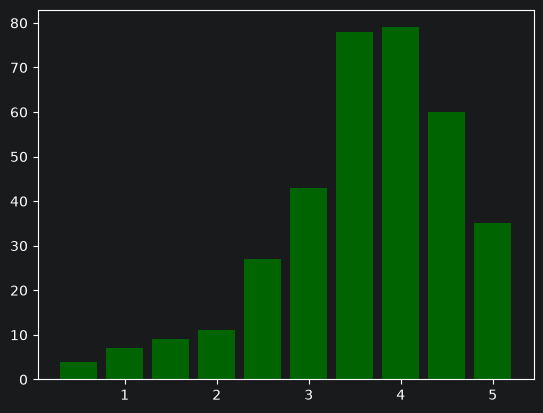

In [35]:
plt.bar(rating_counts.index, rating_counts, color="darkgreen", width=0.4)

<Axes: xlabel='Rating', ylabel='BoxOffice'>

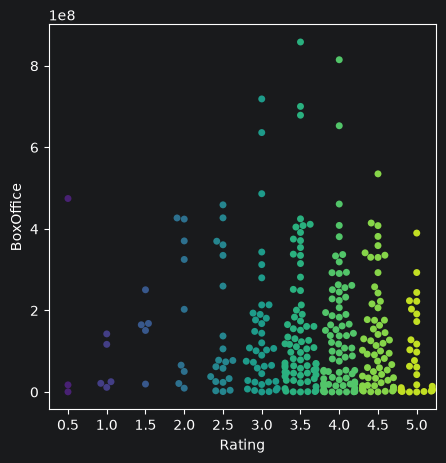

In [36]:
plt.figure(figsize=(5,5))
sns.swarmplot(x="Rating", y="BoxOffice", data=data_df, palette="viridis")

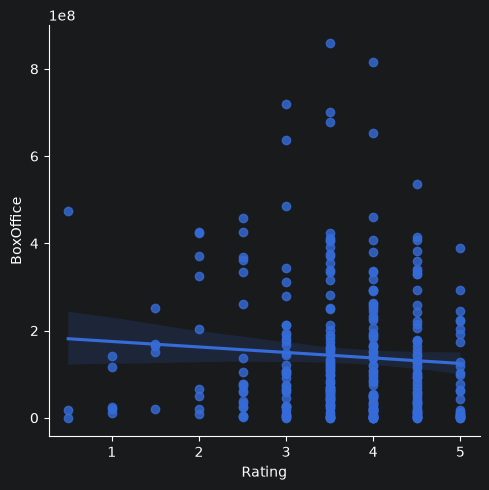

In [37]:
sns.lmplot(data=data_df, x="Rating", y="BoxOffice", palette="viridis")

In [38]:
corr_df = data_df.corr(numeric_only=True)
corr_df.dropna(axis=0, how="all", inplace=True)
corr_df.dropna(axis=1, how="all", inplace=True)
corr_df

,Year,Metascore,imdbRating,BoxOffice,Rating
Year,1.000000,-0.121506,-0.369218,0.126647,-0.208113
Metascore,-0.121506,1.000000,0.696905,0.004496,0.248219
imdbRating,-0.369218,0.696905,1.000000,0.077526,0.430224
BoxOffice,0.126647,0.004496,0.077526,1.000000,-0.075531
Rating,-0.208113,0.248219,0.430224,-0.075531,1.000000


<Axes: >

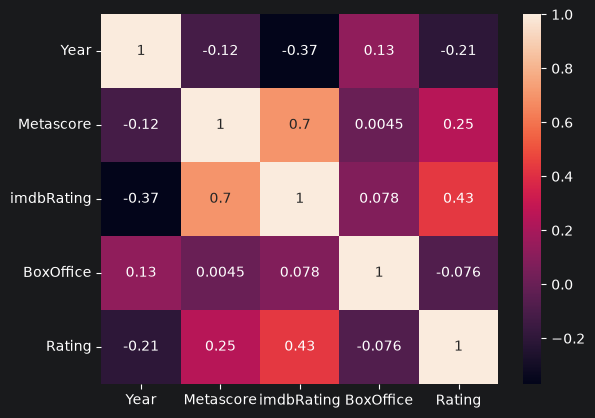

In [39]:
sns.heatmap(data=corr_df, annot=True)

ValueError: could not convert string to float: '2021–2023'

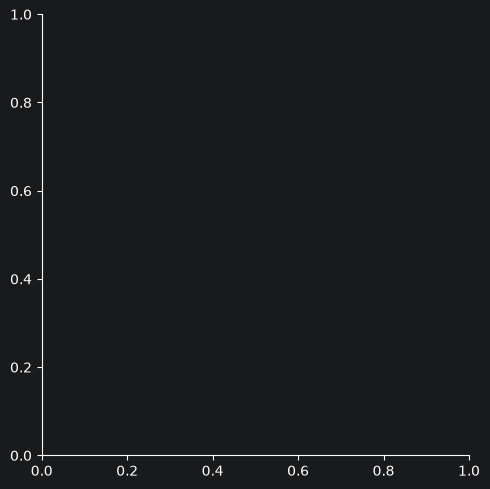

In [15]:
sns.lmplot(data=data_df, x="Rating", y="Year", palette="viridis")

In [16]:
anti_df = ratings_df.merge(movies_df, how="left_anti", left_on="Name", right_on="Title")["Name"]

In [17]:
anti_df.head()

25                       Amélie
69                    Vizontele
119                     Memento
138    The Nightingale of Bursa
140      Grave of the Fireflies
Name: Name, dtype: str

<Axes: xlabel='Rating', ylabel='imdbRating'>

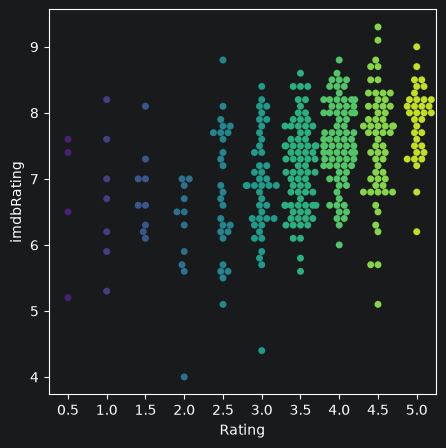

In [40]:
plt.figure(figsize=(5,5))
sns.swarmplot(x="Rating", y="imdbRating", data=data_df, palette="viridis")